# EE-411 Lottery Ticket Hypothesis - Experiment Resnet-18 + Iterative + Random Init + Learning Rate = 0.01 Warmup + 3 Trials

**Author:** Tianrui (Jerry)
**Model:** ResNet 18
**Dataset:** [CIFAR-10]  
**Date:** [2026.01.14]

---

## Instructions

1. **Define your model** in the "Model Definition" section
2. **Train baseline model** to get initial performance
3. **Run pruning experiments** using the shared pruning algorithms
4. **Visualize and analyze** your results
5. **Save your results** to the `results/` folder

## Quick Links

- [Paper](https://arxiv.org/abs/1803.03635): "The Lottery Ticket Hypothesis"
- [Shared Code](../../shared/): Training utils and pruning algorithms
- [Results](../../results/): Save checkpoints and figures here

## Setup Run ID

In [ ]:
import os
import time
from datetime import datetime

# 1. Generate a unique Run ID (Model + Timestamp)
# e.g., "resnet20_20231027_153045"
model_name = "resnet20_iterative_random_init_LR_0.01_warmup_3_trials"  # Or "resnet18"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_id = f"{model_name}_{timestamp}"

# 2. Create specific directories for THIS run
# Instead of dumping everything in 'results/', we make a subfolder
base_dir = "../../results"
run_dir = os.path.join(base_dir, run_id)
ckpt_dir = os.path.join(run_dir, "checkpoints")
fig_dir = os.path.join(run_dir, "figures")

os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

print(f"Experiment Initialized: {run_id}")
print(f"Results will be saved to: {run_dir}")

Experiment Initialized: resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904
Results will be saved to: ../../results/resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904


## 1. Setup and Imports

In [2]:
import sys
sys.path.append('../..')  # Add project root to path

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import shared utilities
from shared.training_utils import fit, predict, set_seed, plot_loss
from shared.pruning import (
    iterative_pruning,
    one_shot_pruning,
    one_shot_pruning_efficient,
    random_reinit_pruning,
    get_pruning_config,
    count_parameters,
    evaluate_model,
    apply_mask,
    create_global_mask
)

# Fix random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Data Loading

### For CIFAR-10 (Conv-2, Conv-4, Conv-6, ResNet-18)

In [3]:
# CIFAR-10 Data Loading


# Define transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # New ! Crucial for CIFAR-10 
    transforms.RandomHorizontalFlip(),     # New ! Crucial for generalization 
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])


# ============================================================================
# 2. Download and Load Datasets (Twice!)
# ============================================================================

# transform_train
train_set_augmented = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=True, 
    download=True, 
    transform=transform_train  # <--- Augmented data
)

# transform_test
train_set_clean = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=True, 
    download=True, 
    transform=transform_test   # <--- Clean data
)

test_dataset = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=False, 
    download=True, 
    transform=transform_test
)



# ============================================================================
# 3. Split Train/Val using Indices
# ============================================================================
# Make sure it's able to reproduce the same split every time
num_train = len(train_set_augmented) # 50000
indices = list(range(num_train))
split = 45000
seed = 42 

np.random.seed(seed)
np.random.shuffle(indices)

train_idx = indices[:split]
val_idx = indices[split:]

# train_dataset
train_dataset = Subset(train_set_augmented, train_idx)
# val_dataset construction using clean data
val_dataset   = Subset(train_set_clean, val_idx)


# ============================================================================
# 4. Create Data Loaders
# ============================================================================
# Create data loaders
# batch_size = 60  # From paper
batch_size = 128  # Paper uses 128 for ResNet-18

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

# ============================================================================
# 5. Verify & Config Check
# ============================================================================

print(f"Train: {len(train_dataset)} samples")
print(f"Val:   {len(val_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")
print(f"Batches per epoch: {len(train_loader)}")

# Automatic Epochs Recommendation
iterations_needed = 30000
steps_per_epoch = len(train_loader)
recommended_epochs = int(np.ceil(iterations_needed / steps_per_epoch))

print(f"\n[Config Check]")
print(f"To reach {iterations_needed} iterations with batch size {batch_size}:")
print(f"You should set EPOCHS >= {recommended_epochs}")

Train: 45000 samples
Val:   5000 samples
Test:  10000 samples
Batches per epoch: 352

[Config Check]
To reach 30000 iterations with batch size 128:
You should set EPOCHS >= 86


## 3. Model Definition

**TODO: Define your model here**

In [4]:
# ResNet18 for CIFAR-10
import copy
import torch
import torch.nn as nn
# from torchvision.models import resnet18
import torch.nn.functional as F
import torch.nn.init as init



# # ResNet-20 for CIFAR-10 (Kaiming He, used in the paper)
# def _weights_init(m):
#     """
#     Kaiming Initialization (He Initialization) as used in the paper.
#     """
#     if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
#         init.kaiming_normal_(m.weight)

def _weights_init(m):
    """
    Paper uses Gaussian Glorot (Xavier Normal) initialization.
    """
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
        # Gaussian Glorot (Xavier Normal) is used in the paper
        init.xavier_normal_(m.weight)
        # If there is bias, typically initialized to 0 (though ResNet's Conv usually doesn't have bias)
        if m.bias is not None:
            init.constant_(m.bias, 0)

            

class LambdaLayer(nn.Module):
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.downsample = nn.Sequential() # named as "downsample" as pruning.py
        if stride != 1 or in_planes != planes:
            # Paper Option A: Zero-padding for shortcut
            self.downsample = LambdaLayer(lambda x:
                                        F.pad(x[:, :, ::2, ::2], (0, 0, 0, 0, planes//4, planes//4), "constant", 0))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.downsample(x)
        out = F.relu(out)
        return out

class ResNet20_CIFAR10(nn.Module):
    def __init__(self):
        super(ResNet20_CIFAR10, self).__init__()
        self.in_planes = 16
        
        # ResNet-20: 3 layers * 3 blocks * 2 convs + 1st conv + 1 linear = 20 layers
        num_blocks = [3, 3, 3] 

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.layer1 = self._make_layer(BasicBlock, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(BasicBlock, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(BasicBlock, 64, num_blocks[2], stride=2)
        
        self.linear = nn.Linear(64, 10)
        
        # Apply initialization
        self.apply(_weights_init)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, out.size()[3])
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out



# Create model instance
# model = ResNet18_CIFAR10().to(device)
model = ResNet20_CIFAR10().to(device)
initial_weights_state = copy.deepcopy(model.state_dict())
init_weights_path = os.path.join(ckpt_dir, f"initial_weights_theta0_{run_id}.pth")
torch.save(initial_weights_state, init_weights_path)
print(f"Initial weights saved to: {init_weights_path}")

# Print model info
total_params = count_parameters(model)
print(f"Model: ResNet20_CIFAR10")
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

Initial weights saved to: ../../results/resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904/checkpoints/initial_weights_theta0_resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904.pth
Model: ResNet20_CIFAR10
Total parameters: 269,722

Model architecture:
ResNet20_CIFAR10(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel

## 4. Baseline Training

Train the unpruned model to establish baseline performance.

In [5]:
# Training configuration (from paper)
# Adjust these based on your model!
     
learning_rate = 0.1 # Paper recommends 0.1 (or 0.03 with warmup)
epochs = 86  

# Optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

optimizer = torch.optim.SGD(
    model.parameters(), 
    lr=learning_rate,             # Paper recommends 0.1 for constant, or 0.03 with warmup
    momentum=0.9, 
    weight_decay=1e-4   # Helps prevent overfitting
)

# Paper: Divide LR by 10 at 20k and 25k iterations
# 20,000 / 352 ≈ 57 epochs
# 25,000 / 352 ≈ 71 epochs
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, 
    milestones=[57, 71], 
    gamma=0.01
)

# --- Dynamic Print ---
optimizer_name = optimizer.__class__.__name__
current_lr = optimizer.param_groups[0]['lr']

print(f"Training configuration:")
print(f"  Optimizer: {optimizer_name}") # Dynamic!
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {epochs}")
print(f"  Batch size: {batch_size}")
print(f"\nStarting training...\n")

test_loss, test_accuracy = predict(model, test_loader, device)

Training configuration:
  Optimizer: SGD
  Learning rate: 0.1
  Epochs: 86
  Batch size: 128

Starting training...

Test set: Avg. loss: 2.8741, Accuracy: 1049/10000 (10%)


In [ ]:
# # Train using shared training_utils
# losses = fit(
#     model=model,
#     train_dataloader=train_loader,
#     optimizer=optimizer,
#     epochs=epochs,
#     device=device,
#     scheduler=scheduler  # New! Don't forget to pass the scheduler!
# )

# # Evaluate on test set
# test_loss, test_accuracy = predict(model, test_loader, device)

# print(f"\n{'='*60}")
# print(f"Baseline Results")
# print(f"{'='*60}")
# print(f"Test Accuracy: {test_accuracy:.2f}%")
# print(f"Test Loss: {test_loss:.4f}")

### Visualize Training

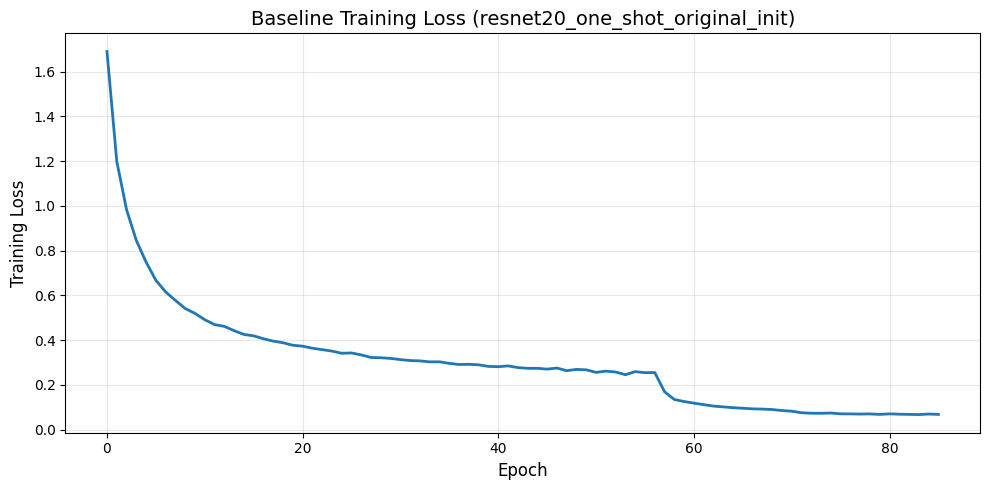

Loss figure saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/figures/baseline_loss_resnet20_one_shot_original_init_20260110_215316.png


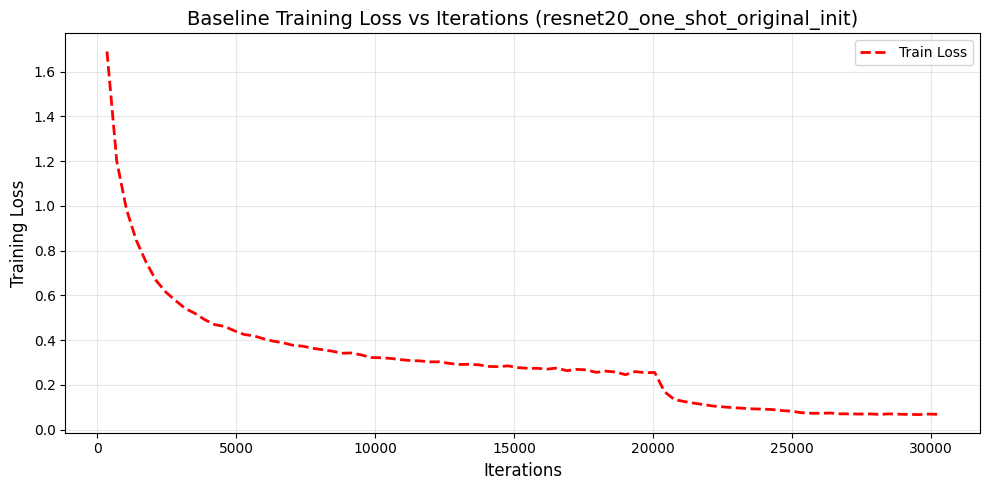

Iteration-based loss figure saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/figures/baseline_loss_iter_resnet20_one_shot_original_init_20260110_215316.png


In [ ]:
# iterations_per_epoch = len(train_loader)
# # ================= Drawing Figure 1: X-axis = Epochs =================

# plt.figure(figsize=(10, 5))
# plt.plot(losses, linewidth=2)
# plt.xlabel('Epoch', fontsize=12)
# plt.ylabel('Training Loss', fontsize=12)
# plt.title(f'Baseline Training Loss ({model_name})', fontsize=14)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()

# # Save with run_id
# loss_fig_path = os.path.join(fig_dir, f"baseline_loss_{run_id}.png")
# plt.savefig(loss_fig_path, dpi=150)
# plt.show()

# print(f"Loss figure saved to: {loss_fig_path}")

# # ================= Drawing Figure 2: X-axis = Iterations =================
# iterations_x = [i * iterations_per_epoch for i in range(1, len(losses) + 1)]

# plt.figure(figsize=(10, 5))
# plt.plot(iterations_x, losses, linewidth=2, color='red', linestyle='--', label='Train Loss')
# plt.xlabel('Iterations', fontsize=12)
# plt.ylabel('Training Loss', fontsize=12)
# plt.title(f'Baseline Training Loss vs Iterations ({model_name})', fontsize=14)
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()

# # Save Iteration Figure
# loss_fig_path_iter = os.path.join(fig_dir, f"baseline_loss_iter_{run_id}.png")
# plt.savefig(loss_fig_path_iter, dpi=150)
# plt.show()
# print(f"Iteration-based loss figure saved to: {loss_fig_path_iter}")

### Save Baseline Model

In [ ]:
# # --- Save Baseline Model ---
# # Save with the unique run_id in the filename
# baseline_path = os.path.join(ckpt_dir, f"baseline_{run_id}.pth")

# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'test_accuracy': test_accuracy,
#     'test_loss': test_loss,
#     'epochs': epochs,
#     'config': {
#         'optimizer': optimizer_name,
#         'lr': current_lr
#     }
# }, baseline_path)

# print(f"Baseline model saved to: {baseline_path}")

Baseline model saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/checkpoints/baseline_resnet20_one_shot_original_init_20260110_215316.pth


## 5. Pruning Experiments

### 5.1 Iterative Pruning

Run the main pruning experiment from the paper.

In [6]:
# Get pruning configuration for your model
# Options: 'lenet', 'conv2', 'conv4', 'conv6', 'resnet18', 'resnet20'

pruning_config = get_pruning_config('resnet20')

print("Pruning Configuration:")
for key, value in pruning_config.items():
    print(f"  {key}: {value}")


Pruning Configuration:
  prune_rate_conv: 0.2
  prune_rate_fc: 0.0
  pruning_strategy: global
  warmup_strategy: linear_20k
  description: ResNet-20 LR=0.03 Warmup=20k


In [7]:
# --- Seed Configuration for Trials ---
SEEDS = [42, 43, 44]
lr = 0.01
epochs_per_round = 86  # ~30k iterations

# --- Data Preparation Function (Re-usable for every seed) ---
def get_dataloaders(seed):
    """Re-creates dataloaders with specific seed-based shuffling"""
    
    # Define transforms
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    # Load Datasets
    train_set_augmented = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=transform_train)
    train_set_clean = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=transform_test)
    test_dataset = torchvision.datasets.CIFAR10(root='../../data', train=False, download=True, transform=transform_test)

    # Split Train/Val (Dependent on Seed)
    num_train = len(train_set_augmented)
    indices = list(range(num_train))
    split = 45000
    
    # Temporarily set numpy seed for split consistency within this function call
    rng = np.random.RandomState(seed) 
    rng.shuffle(indices)

    train_idx = indices[:split]
    val_idx = indices[split:]

    train_dataset = Subset(train_set_augmented, train_idx)
    val_dataset = Subset(train_set_clean, val_idx)

    # Create Loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    return train_loader, val_loader, test_loader


In [8]:
# ============================================================================
# PHASE 1: Iterative Pruning (Winning Tickets)
# ============================================================================
print(f"\n{'='*40}")
print("PHASE 1: Iterative Pruning Experiments")
print(f"{'='*40}")

all_trials_iterative = []

for trial_idx, seed in enumerate(SEEDS):
    print(f"\n>>> Starting Iterative Trial {trial_idx + 1}/{len(SEEDS)} | Seed {seed}")
    
    # 1. Set seed for reproducibility
    set_seed(seed)
    
    # 2. Prepare Data & Model
    train_loader, val_loader, test_loader = get_dataloaders(seed)
    model = ResNet20_CIFAR10().to(device)
    
    # 3. Run Iterative Pruning
    iter_results = iterative_pruning(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        val_loader=val_loader,
        optimizer_class=torch.optim.SGD,
        optimizer_kwargs={'lr': lr, 'momentum': 0.9, 'weight_decay': 1e-4},
        device=device,
        config=pruning_config,
        epochs_per_round=epochs_per_round,
        n_rounds=15,
        verbose=True
    )
    
    all_trials_iterative.append(iter_results)

# 4. Save Iterative Results immediately
iterative_save_path = os.path.join(ckpt_dir, f"iterative_results_{run_id}.pth")
torch.save({
    'trials': all_trials_iterative,
    'seeds': SEEDS,
    'config': pruning_config,
    'lr': lr
}, iterative_save_path)
print(f"Saved Iterative results to: {iterative_save_path}")


PHASE 1: Iterative Pruning Experiments

>>> Starting Iterative Trial 1/3 | Seed 42

Seed set to: 42
Starting Iterative Pruning
Initial parameters: 269,722
Pruning strategy: global
Conv prune rate: 20.0%
FC prune rate: 0.0%
Warmup strategy: linear_20k

Round 1/15
Scheduler enabled: Linear Warmup to epoch 57, then decay.
Epoch 01 | Train Loss: 2.2587 | Val Loss: 1.9737 | Val Acc: 25.78% | Test Acc: 25.57%
Epoch 02 | Train Loss: 1.8798 | Val Loss: 1.7558 | Val Acc: 35.56% | Test Acc: 35.69%
Epoch 03 | Train Loss: 1.6989 | Val Loss: 1.5947 | Val Acc: 39.98% | Test Acc: 41.51%
Epoch 04 | Train Loss: 1.5798 | Val Loss: 1.5268 | Val Acc: 43.04% | Test Acc: 44.18%
Epoch 05 | Train Loss: 1.4854 | Val Loss: 1.4548 | Val Acc: 47.50% | Test Acc: 47.32%
Epoch 06 | Train Loss: 1.3947 | Val Loss: 1.3667 | Val Acc: 50.46% | Test Acc: 51.35%
Epoch 07 | Train Loss: 1.3159 | Val Loss: 1.2716 | Val Acc: 54.48% | Test Acc: 55.09%
Epoch 08 | Train Loss: 1.2299 | Val Loss: 1.3610 | Val Acc: 52.98% | Test Ac

Epoch 10/86: 100%|██████████| 352/352 [00:05<00:00, 63.72it/s]


Epoch 10 | Train Loss: 1.0945 | Val Loss: 1.1619 | Val Acc: 58.90% | Test Acc: 60.24%
Epoch 11 | Train Loss: 1.0397 | Val Loss: 1.0639 | Val Acc: 62.60% | Test Acc: 62.92%
Epoch 12 | Train Loss: 0.9872 | Val Loss: 1.1206 | Val Acc: 62.34% | Test Acc: 62.55%
Epoch 13 | Train Loss: 0.9397 | Val Loss: 1.2235 | Val Acc: 61.12% | Test Acc: 61.65%
Epoch 14 | Train Loss: 0.8983 | Val Loss: 1.0275 | Val Acc: 65.56% | Test Acc: 64.90%
Epoch 15 | Train Loss: 0.8571 | Val Loss: 0.9247 | Val Acc: 68.64% | Test Acc: 68.20%
Epoch 16 | Train Loss: 0.8216 | Val Loss: 1.0808 | Val Acc: 64.80% | Test Acc: 65.92%
Epoch 17 | Train Loss: 0.7883 | Val Loss: 0.8993 | Val Acc: 69.22% | Test Acc: 69.42%
Epoch 18 | Train Loss: 0.7568 | Val Loss: 0.9128 | Val Acc: 69.30% | Test Acc: 69.42%
Epoch 19 | Train Loss: 0.7251 | Val Loss: 0.9382 | Val Acc: 69.18% | Test Acc: 69.11%


Epoch 20/86: 100%|██████████| 352/352 [00:05<00:00, 65.35it/s]


Epoch 20 | Train Loss: 0.6986 | Val Loss: 0.9463 | Val Acc: 69.16% | Test Acc: 68.71%
Epoch 21 | Train Loss: 0.6711 | Val Loss: 0.8869 | Val Acc: 71.58% | Test Acc: 71.62%
Epoch 22 | Train Loss: 0.6535 | Val Loss: 0.7834 | Val Acc: 74.18% | Test Acc: 74.03%
Epoch 23 | Train Loss: 0.6256 | Val Loss: 0.8018 | Val Acc: 73.40% | Test Acc: 73.53%
Epoch 24 | Train Loss: 0.6128 | Val Loss: 0.7611 | Val Acc: 74.40% | Test Acc: 75.29%
Epoch 25 | Train Loss: 0.5882 | Val Loss: 0.6903 | Val Acc: 76.66% | Test Acc: 76.51%
Epoch 26 | Train Loss: 0.5696 | Val Loss: 0.7886 | Val Acc: 73.34% | Test Acc: 74.01%
Epoch 27 | Train Loss: 0.5542 | Val Loss: 0.6927 | Val Acc: 77.58% | Test Acc: 77.56%
Epoch 28 | Train Loss: 0.5430 | Val Loss: 0.6576 | Val Acc: 78.64% | Test Acc: 77.76%
Epoch 29 | Train Loss: 0.5265 | Val Loss: 0.6357 | Val Acc: 78.04% | Test Acc: 78.90%


...

Epoch 60 | Train Loss: 0.2832 | Val Loss: 0.3735 | Val Acc: 87.42% | Test Acc: 86.82%
Epoch 61 | Train Loss: 0.2786 | Val Loss: 0.3736 | Val Acc: 87.32% | Test Acc: 86.83%
Epoch 62 | Train Loss: 0.2757 | Val Loss: 0.3699 | Val Acc: 87.60% | Test Acc: 86.92%
Epoch 63 | Train Loss: 0.2759 | Val Loss: 0.3737 | Val Acc: 87.42% | Test Acc: 86.71%
Epoch 64 | Train Loss: 0.2747 | Val Loss: 0.3658 | Val Acc: 87.86% | Test Acc: 87.03%
Epoch 65 | Train Loss: 0.2710 | Val Loss: 0.3712 | Val Acc: 87.56% | Test Acc: 86.94%
Epoch 66 | Train Loss: 0.2721 | Val Loss: 0.3724 | Val Acc: 87.48% | Test Acc: 86.97%
Epoch 67 | Train Loss: 0.2698 | Val Loss: 0.3707 | Val Acc: 87.52% | Test Acc: 86.86%
Epoch 68 | Train Loss: 0.2702 | Val Loss: 0.3682 | Val Acc: 87.92% | Test Acc: 86.91%
Epoch 69 | Train Loss: 0.2681 | Val Loss: 0.3731 | Val Acc: 87.34% | Test Acc: 86.84%


Epoch 70/86: 100%|██████████| 352/352 [00:05<00:00, 61.96it/s]


Epoch 70 | Train Loss: 0.2701 | Val Loss: 0.3719 | Val Acc: 87.86% | Test Acc: 86.73%
Epoch 71 | Train Loss: 0.2630 | Val Loss: 0.3756 | Val Acc: 87.76% | Test Acc: 86.84%
 -> Scheduler Step! Current LR: 0.0001
Epoch 72 | Train Loss: 0.2636 | Val Loss: 0.3722 | Val Acc: 87.56% | Test Acc: 86.90%
 -> Scheduler Step! Current LR: 0.0001
Epoch 73 | Train Loss: 0.2648 | Val Loss: 0.3724 | Val Acc: 87.70% | Test Acc: 87.05%
   [Tracker] 🚩 Early Stop Condition at Iter 26048 (Epoch 74, Test Acc: 87.16%)
Epoch 74 | Train Loss: 0.2626 | Val Loss: 0.3709 | Val Acc: 87.80% | Test Acc: 87.16%
Epoch 75 | Train Loss: 0.2622 | Val Loss: 0.3722 | Val Acc: 87.74% | Test Acc: 87.04%
Epoch 76 | Train Loss: 0.2614 | Val Loss: 0.3716 | Val Acc: 87.82% | Test Acc: 87.03%
Epoch 77 | Train Loss: 0.2639 | Val Loss: 0.3723 | Val Acc: 87.52% | Test Acc: 87.03%
Epoch 78 | Train Loss: 0.2645 | Val Loss: 0.3699 | Val Acc: 87.70% | Test Acc: 87.21%
Epoch 79 | Train Loss: 0.2607 | Val Loss: 0.3712 | Val Acc: 87.70% | 

Epoch 80/86: 100%|██████████| 352/352 [00:05<00:00, 63.37it/s]


Epoch 80 | Train Loss: 0.2627 | Val Loss: 0.3717 | Val Acc: 87.72% | Test Acc: 87.07%
Epoch 81 | Train Loss: 0.2612 | Val Loss: 0.3710 | Val Acc: 87.60% | Test Acc: 87.08%
Epoch 82 | Train Loss: 0.2563 | Val Loss: 0.3706 | Val Acc: 87.80% | Test Acc: 87.08%
Epoch 83 | Train Loss: 0.2610 | Val Loss: 0.3731 | Val Acc: 87.76% | Test Acc: 87.09%
Epoch 84 | Train Loss: 0.2611 | Val Loss: 0.3699 | Val Acc: 87.76% | Test Acc: 87.09%
Epoch 85 | Train Loss: 0.2608 | Val Loss: 0.3708 | Val Acc: 87.68% | Test Acc: 86.98%
Epoch 86 | Train Loss: 0.2605 | Val Loss: 0.3715 | Val Acc: 87.66% | Test Acc: 86.96%

Round 15 Results:
  Test Accuracy: 86.96%
  Remaining Parameters: 11,444.0 (4.24%)

Iterative Pruning Complete!
Saved Iterative results to: ../../results/resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904/checkpoints/iterative_results_resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904.pth


In [9]:
# --- Data Aggregation ---
# Assuming all trials have the same number of rounds and pruning rates
n_rounds = len(all_trials_iterative[0])
n_trials = len(all_trials_iterative)

# Initialize lists to store aggregated data
rounds = []
remaining_params_pct = []
remaining_params = []
acc_means = []
acc_stds = []

for r_idx in range(n_rounds):
    # Extract data for this specific round across all trials
    # Structure: [Trial1_RoundX, Trial2_RoundX, Trial3_RoundX]
    round_data = [trial[r_idx] for trial in all_trials_iterative]
    
    # Static data (same for all trials)
    rounds.append(round_data[0]['round'])
    remaining_params_pct.append(round_data[0]['remaining_params_pct'])
    remaining_params.append(round_data[0]['remaining_params'])
    
    # Variable data (Accuracy) - Calculate Mean and Std
    accuracies = [r['test_accuracy'] for r in round_data]
    acc_means.append(np.mean(accuracies))
    acc_stds.append(np.std(accuracies))

# --- Print Summary Table ---
print("\n" + "="*80)
print(f"Pruning Results Summary ({n_trials} Trials Aggregated)")
print("="*80)
print(f"{'Round':<8} {'Params %':<12} {'Params':<15} {'Mean Acc %':<12} {'Std Dev':<10}")
print("-"*80)

for i in range(n_rounds):
    print(f"{rounds[i]:<8} {remaining_params_pct[i]:<12.2f} "
          f"{remaining_params[i]:<15,} {acc_means[i]:<12.2f} ± {acc_stds[i]:<10.2f}")
print("="*80)


Pruning Results Summary (3 Trials Aggregated)
Round    Params %     Params          Mean Acc %   Std Dev   
--------------------------------------------------------------------------------
1        80.15        216,183.0       88.23        ± 0.10      
2        64.27        173,351.0       88.89        ± 0.13      
3        51.57        139,086.0       89.04        ± 0.15      
4        41.40        111,674.0       89.03        ± 0.06      
5        33.27        89,744.0        89.20        ± 0.06      
6        26.77        72,200.0        89.26        ± 0.02      
7        21.56        58,165.0        89.24        ± 0.12      
8        17.40        46,937.0        89.17        ± 0.09      
9        14.07        37,955.0        89.00        ± 0.11      
10       11.41        30,769.0        88.71        ± 0.05      
11       9.28         25,020.0        88.71        ± 0.07      
12       7.57         20,421.0        88.29        ± 0.30      
13       6.21         16,742.0        87.9

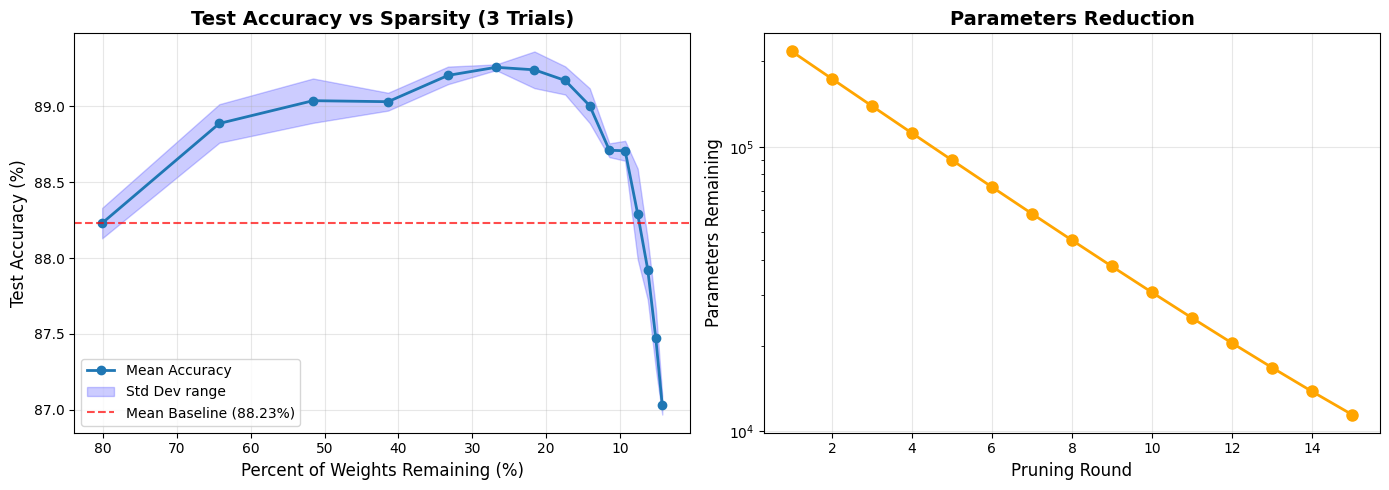

Pruning figure saved to: ../../results/resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904/figures/Iterative_pruning_results_multi_trial_resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904.png


In [10]:
# --- Visualize with Error Bars ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convert to numpy arrays for plotting
x_pct = np.array(remaining_params_pct)
y_mean = np.array(acc_means)
y_std = np.array(acc_stds)

# Plot 1: Accuracy vs Sparsity (Mean + Std Shadow)
# Plot the mean line
ax1.plot(x_pct, y_mean, 'o-', linewidth=2, markersize=6, label='Mean Accuracy')

# Plot the shadow (Mean +/- Std) 

ax1.fill_between(x_pct, y_mean - y_std, y_mean + y_std, alpha=0.2, color='blue', label='Std Dev range')

# Baseline Handling: Calculate mean baseline from Round 1 (0% pruned)
baseline_mean = y_mean[0] 
ax1.axhline(y=baseline_mean, color='r', linestyle='--', label=f'Mean Baseline ({baseline_mean:.2f}%)', alpha=0.7)

ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title(f'Test Accuracy vs Sparsity ({n_trials} Trials)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.invert_xaxis()  # 100% -> 0%

# Plot 2: Params Reduction (Deterministic, no error bars needed)
ax2.plot(rounds, remaining_params, 'o-', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Pruning Round', fontsize=12)
ax2.set_ylabel('Parameters Remaining', fontsize=12)
ax2.set_title('Parameters Reduction', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log') 

plt.tight_layout()

# Save Pruning Figure
# Ensure fig_dir exists in your context
pruning_fig_path = os.path.join(fig_dir, f"Iterative_pruning_results_multi_trial_{run_id}.png")
plt.savefig(pruning_fig_path, dpi=150)
plt.show()

print(f"Pruning figure saved to: {pruning_fig_path}")

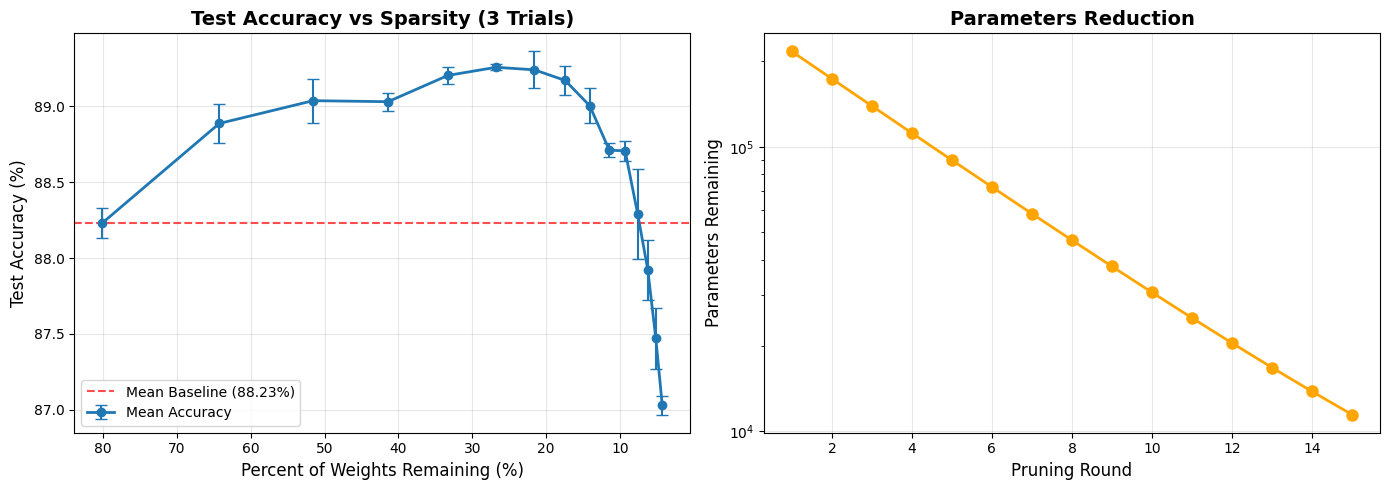

Pruning figure saved to: ../../results/resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904/figures/Iterative_pruning_results_multi_trial_errorbars_resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904.png


In [11]:
import matplotlib.pyplot as plt
import os
import numpy as np

# --- Visualize with Error Bars (Vertical Lines) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convert to numpy arrays for plotting
x_pct = np.array(remaining_params_pct)
y_mean = np.array(acc_means)
y_std = np.array(acc_stds)

# ==============================================================================
# Plot 1: Accuracy vs Sparsity (Using Error Bars)
# ==============================================================================

# ax1.errorbar 是关键函数
# x, y: 坐标
# yerr: 误差范围 (这里用标准差)
# fmt='o-': 样式 (圆点 + 实线)
# capsize=4: 误差棒顶部和底部的小横杠宽度 (让它看起来更像论文)
# elinewidth=1.5: 误差棒的线条粗细
ax1.errorbar(x_pct, y_mean, yerr=y_std, fmt='o-', 
             linewidth=2, markersize=6, capsize=4, elinewidth=1.5,
             color='tab:blue', ecolor='tab:blue', label='Mean Accuracy')

# Baseline Handling
baseline_mean = y_mean[0] 
ax1.axhline(y=baseline_mean, color='r', linestyle='--', label=f'Mean Baseline ({baseline_mean:.2f}%)', alpha=0.7)

ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title(f'Test Accuracy vs Sparsity ({n_trials} Trials)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.invert_xaxis()  # 100% -> 0% (Standard for pruning plots)

# ==============================================================================
# Plot 2: Params Reduction (No changes needed)
# ==============================================================================
ax2.plot(rounds, remaining_params, 'o-', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Pruning Round', fontsize=12)
ax2.set_ylabel('Parameters Remaining', fontsize=12)
ax2.set_title('Parameters Reduction', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log') 

plt.tight_layout()

# Save Pruning Figure
if 'fig_dir' not in globals(): fig_dir = "." # Fallback if fig_dir is not defined
pruning_fig_path = os.path.join(fig_dir, f"Iterative_pruning_results_multi_trial_errorbars_{run_id}.png")
plt.savefig(pruning_fig_path, dpi=300) # Increased DPI for better quality
plt.show()

print(f"Pruning figure saved to: {pruning_fig_path}")

In [12]:
# --- Identify Winning Tickets (Based on Mean Accuracy) ---

# Define Baseline: Mean accuracy of the unpruned model (Round 1)
baseline_mean_acc = acc_means[0] 

winning_tickets_indices = []

# Loop through aggregated stats
for i in range(n_rounds):
    # Criteria: Mean Accuracy >= 98% of Mean Baseline
    if acc_means[i] >= baseline_mean_acc * 0.98:
        winning_tickets_indices.append(i)

print(f"\n{'='*70}")
print(f"Winning Ticket Analysis (Based on {n_trials} Trials Mean)")
print(f"{'='*70}")
print(f"Mean Baseline Accuracy: {baseline_mean_acc:.2f}%")
print(f"\nWinning Tickets (Mean Acc >= {baseline_mean_acc * 0.98:.2f}%):")
print(f"{'Round':<8} {'Sparsity %':<12} {'Params':<15} {'Mean Acc %':<12}")
print("-"*70)

best_ticket_idx = -1
min_params = float('inf')

for idx in winning_tickets_indices:
    sparsity = 100 - remaining_params_pct[idx]
    print(f"{rounds[idx]:<8} {sparsity:<12.1f} "
          f"{remaining_params[idx]:<15,} {acc_means[idx]:<12.2f}")
    
    # Track the best ticket (most sparse)
    if remaining_params[idx] < min_params:
        min_params = remaining_params[idx]
        best_ticket_idx = idx

if best_ticket_idx != -1:
    print(f"\nBest Winning Ticket (Most Sparse):")
    print(f"  Round: {rounds[best_ticket_idx]}")
    print(f"  Sparsity: {100 - remaining_params_pct[best_ticket_idx]:.1f}%")
    print(f"  Parameters: {remaining_params[best_ticket_idx]:,}")
    print(f"  Mean Accuracy: {acc_means[best_ticket_idx]:.2f}%")


Winning Ticket Analysis (Based on 3 Trials Mean)
Mean Baseline Accuracy: 88.23%

Winning Tickets (Mean Acc >= 86.47%):
Round    Sparsity %   Params          Mean Acc %  
----------------------------------------------------------------------
1        19.8         216,183.0       88.23       
2        35.7         173,351.0       88.89       
3        48.4         139,086.0       89.04       
4        58.6         111,674.0       89.03       
5        66.7         89,744.0        89.20       
6        73.2         72,200.0        89.26       
7        78.4         58,165.0        89.24       
8        82.6         46,937.0        89.17       
9        85.9         37,955.0        89.00       
10       88.6         30,769.0        88.71       
11       90.7         25,020.0        88.71       
12       92.4         20,421.0        88.29       
13       93.8         16,742.0        87.92       
14       94.9         13,799.0        87.47       
15       95.8         11,444.0        87.03 

### 5.2 Random Init

In [13]:
# ============================================================================
# PHASE 2: Random Reinitialization (Control)
# ============================================================================
print(f"\n{'='*40}")
print("PHASE 2: Random Reinitialization Experiments")
print(f"{'='*40}")

all_trials_random = []

for trial_idx, seed in enumerate(SEEDS):
    print(f"\n>>> Starting Random Init Trial {trial_idx + 1}/{len(SEEDS)} | Seed {seed}")
    
    # 1. Set seed (Ensure data shuffle matches Phase 1)
    set_seed(seed)
    
    # 2. Prepare Data
    train_loader, val_loader, test_loader = get_dataloaders(seed)
    
    # 3. Retrieve Masks from Phase 1
    current_iter_results = all_trials_iterative[trial_idx]
    
    trial_random_results = []
    
    # 4. Create a fresh base model for re-init
    base_model_rnd = ResNet20_CIFAR10().to(device)
    
    # 5. Iterate through rounds using Phase 1 masks
    for res in current_iter_results:
        mask = res['mask']
        if mask is None: continue # Skip Round 0 (no pruning)
        
        print(f"   -> Random Reinit for Sparsity: {res['remaining_params_pct']:.2f}%")
        
        # Run Random Reinit Pruning
        # [CRITICAL UPDATE]: Passing 'config' so the correct scheduler is used
        rand_res = random_reinit_pruning(
            model=copy.deepcopy(base_model_rnd),
            train_loader=train_loader,
            test_loader=test_loader,
            val_loader=val_loader,
            optimizer_class=torch.optim.SGD,
            optimizer_kwargs={'lr': lr, 'momentum': 0.9, 'weight_decay': 1e-4},
            device=device,
            mask=mask,
            # Pass the same config structure you used in Phase 1
            config=pruning_config,
            epochs=epochs_per_round,
            verbose=True 
        )
        
        # Add metadata for plotting
        rand_res['remaining_params_pct'] = res['remaining_params_pct']
        rand_res['round'] = res['round']
        trial_random_results.append(rand_res)
        
    all_trials_random.append(trial_random_results)

# 6. Save Random Init Results separately
random_save_path = os.path.join(ckpt_dir, f"random_init_results_{run_id}.pth")
torch.save({
    'trials': all_trials_random,
    'seeds': SEEDS,
    'config': pruning_config,
    'lr': lr
}, random_save_path)
print(f"Saved Random Init results to: {random_save_path}")


PHASE 2: Random Reinitialization Experiments

>>> Starting Random Init Trial 1/3 | Seed 42

Seed set to: 42
   -> Random Reinit for Sparsity: 80.15%

Starting Random Reinit Control Experiment
Sparsity Level: 80.15% weights remaining
Pruning strategy: global
Conv prune rate: 20.0%
FC prune rate: 0.0%
Warmup strategy: linear_20k
Scheduler enabled: Linear Warmup to epoch 57, then decay.
Epoch 01 | Train Loss: 2.1629 | Val Loss: 1.9541 | Val Acc: 27.96% | Test Acc: 28.68%
Epoch 02 | Train Loss: 1.8568 | Val Loss: 1.7440 | Val Acc: 35.48% | Test Acc: 36.45%
Epoch 03 | Train Loss: 1.6992 | Val Loss: 1.6269 | Val Acc: 40.08% | Test Acc: 39.90%
Epoch 04 | Train Loss: 1.5854 | Val Loss: 1.5259 | Val Acc: 43.72% | Test Acc: 44.15%
Epoch 05 | Train Loss: 1.4944 | Val Loss: 1.5014 | Val Acc: 45.96% | Test Acc: 46.00%
Epoch 06 | Train Loss: 1.3969 | Val Loss: 1.3559 | Val Acc: 49.36% | Test Acc: 50.64%
Epoch 07 | Train Loss: 1.3070 | Val Loss: 1.2623 | Val Acc: 54.48% | Test Acc: 54.56%
Epoch 08 |

Epoch 10/86: 100%|██████████| 352/352 [00:05<00:00, 60.72it/s]


Epoch 10 | Train Loss: 1.0958 | Val Loss: 1.1150 | Val Acc: 60.50% | Test Acc: 61.12%
Epoch 11 | Train Loss: 1.0397 | Val Loss: 1.1548 | Val Acc: 59.46% | Test Acc: 59.89%
Epoch 12 | Train Loss: 0.9837 | Val Loss: 1.1177 | Val Acc: 61.94% | Test Acc: 62.91%
Epoch 13 | Train Loss: 0.9443 | Val Loss: 0.9993 | Val Acc: 65.24% | Test Acc: 65.84%
Epoch 14 | Train Loss: 0.8943 | Val Loss: 0.9602 | Val Acc: 66.62% | Test Acc: 66.63%
Epoch 15 | Train Loss: 0.8507 | Val Loss: 0.8618 | Val Acc: 69.06% | Test Acc: 70.40%
Epoch 16 | Train Loss: 0.8097 | Val Loss: 0.9878 | Val Acc: 66.80% | Test Acc: 66.89%
Epoch 17 | Train Loss: 0.7792 | Val Loss: 0.8638 | Val Acc: 71.14% | Test Acc: 70.86%
Epoch 18 | Train Loss: 0.7482 | Val Loss: 0.8898 | Val Acc: 69.78% | Test Acc: 69.84%
Epoch 19 | Train Loss: 0.7146 | Val Loss: 0.8245 | Val Acc: 71.88% | Test Acc: 72.45%


Epoch 20/86: 100%|██████████| 352/352 [00:05<00:00, 64.89it/s]


Epoch 20 | Train Loss: 0.6900 | Val Loss: 0.8680 | Val Acc: 71.62% | Test Acc: 71.66%
Epoch 21 | Train Loss: 0.6627 | Val Loss: 0.9568 | Val Acc: 69.94% | Test Acc: 69.32%
Epoch 22 | Train Loss: 0.6483 | Val Loss: 0.8057 | Val Acc: 74.08% | Test Acc: 73.44%
Epoch 23 | Train Loss: 0.6254 | Val Loss: 0.7067 | Val Acc: 75.82% | Test Acc: 75.80%
Epoch 24 | Train Loss: 0.6054 | Val Loss: 0.7086 | Val Acc: 76.10% | Test Acc: 76.34%
Epoch 25 | Train Loss: 0.5863 | Val Loss: 0.7525 | Val Acc: 75.24% | Test Acc: 75.96%
Epoch 26 | Train Loss: 0.5705 | Val Loss: 0.8069 | Val Acc: 73.60% | Test Acc: 73.19%
Epoch 27 | Train Loss: 0.5499 | Val Loss: 0.7010 | Val Acc: 77.02% | Test Acc: 76.85%
Epoch 28 | Train Loss: 0.5434 | Val Loss: 0.6179 | Val Acc: 79.02% | Test Acc: 79.11%
Epoch 29 | Train Loss: 0.5244 | Val Loss: 0.7363 | Val Acc: 75.68% | Test Acc: 75.60%


...

Epoch 60 | Train Loss: 0.5857 | Val Loss: 0.5656 | Val Acc: 80.14% | Test Acc: 78.53%
Epoch 61 | Train Loss: 0.5832 | Val Loss: 0.5673 | Val Acc: 80.68% | Test Acc: 78.60%
Epoch 62 | Train Loss: 0.5796 | Val Loss: 0.5642 | Val Acc: 80.76% | Test Acc: 78.68%
Epoch 63 | Train Loss: 0.5794 | Val Loss: 0.5675 | Val Acc: 80.34% | Test Acc: 78.63%
Epoch 64 | Train Loss: 0.5779 | Val Loss: 0.5667 | Val Acc: 80.48% | Test Acc: 78.66%
Epoch 65 | Train Loss: 0.5782 | Val Loss: 0.5650 | Val Acc: 80.66% | Test Acc: 78.56%
Epoch 66 | Train Loss: 0.5737 | Val Loss: 0.5642 | Val Acc: 80.98% | Test Acc: 78.62%
Epoch 67 | Train Loss: 0.5695 | Val Loss: 0.5611 | Val Acc: 80.82% | Test Acc: 78.47%
Epoch 68 | Train Loss: 0.5735 | Val Loss: 0.5555 | Val Acc: 81.04% | Test Acc: 78.63%
Epoch 69 | Train Loss: 0.5688 | Val Loss: 0.5607 | Val Acc: 80.36% | Test Acc: 78.76%


Epoch 70/86: 100%|██████████| 352/352 [00:05<00:00, 63.37it/s]


Epoch 70 | Train Loss: 0.5678 | Val Loss: 0.5607 | Val Acc: 80.96% | Test Acc: 78.87%
Epoch 71 | Train Loss: 0.5665 | Val Loss: 0.5585 | Val Acc: 81.20% | Test Acc: 78.94%
 -> Scheduler Step! Current LR: 0.0001
Epoch 72 | Train Loss: 0.5664 | Val Loss: 0.5572 | Val Acc: 80.78% | Test Acc: 79.01%
 -> Scheduler Step! Current LR: 0.0001
Epoch 73 | Train Loss: 0.5601 | Val Loss: 0.5551 | Val Acc: 80.92% | Test Acc: 79.07%
Epoch 74 | Train Loss: 0.5599 | Val Loss: 0.5549 | Val Acc: 80.90% | Test Acc: 79.11%
Epoch 75 | Train Loss: 0.5587 | Val Loss: 0.5552 | Val Acc: 80.86% | Test Acc: 78.92%
Epoch 76 | Train Loss: 0.5625 | Val Loss: 0.5529 | Val Acc: 80.88% | Test Acc: 79.14%
Epoch 77 | Train Loss: 0.5565 | Val Loss: 0.5548 | Val Acc: 80.88% | Test Acc: 79.12%
Epoch 78 | Train Loss: 0.5636 | Val Loss: 0.5524 | Val Acc: 80.92% | Test Acc: 78.99%
Epoch 79 | Train Loss: 0.5570 | Val Loss: 0.5542 | Val Acc: 80.96% | Test Acc: 79.02%


Epoch 80/86: 100%|██████████| 352/352 [00:05<00:00, 66.28it/s]


Epoch 80 | Train Loss: 0.5614 | Val Loss: 0.5555 | Val Acc: 81.06% | Test Acc: 79.06%
Epoch 81 | Train Loss: 0.5577 | Val Loss: 0.5541 | Val Acc: 80.96% | Test Acc: 79.06%
Epoch 82 | Train Loss: 0.5600 | Val Loss: 0.5525 | Val Acc: 81.20% | Test Acc: 78.96%
Epoch 83 | Train Loss: 0.5610 | Val Loss: 0.5547 | Val Acc: 81.04% | Test Acc: 79.10%
Epoch 84 | Train Loss: 0.5593 | Val Loss: 0.5542 | Val Acc: 81.12% | Test Acc: 79.17%
Epoch 85 | Train Loss: 0.5585 | Val Loss: 0.5545 | Val Acc: 80.96% | Test Acc: 79.14%
   [Tracker] 🚩 Early Stop Condition at Iter 30272 (Epoch 86, Test Acc: 79.00%)
Epoch 86 | Train Loss: 0.5618 | Val Loss: 0.5551 | Val Acc: 81.28% | Test Acc: 79.00%

Random Reinit Result:
  Test Accuracy: 79.00%
  Remaining Params: 4.24%

Saved Random Init results to: ../../results/resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904/checkpoints/random_init_results_resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904.pth


In [14]:
# --- Data Aggregation (Random Init) ---
# Assuming all_trials_random is a List[List[Dict]] populated from your Phase 2 loop
n_rounds_rnd = len(all_trials_random[0])
n_trials_rnd = len(all_trials_random)

# Initialize lists to store aggregated data
rounds_rnd = []
remaining_params_pct_rnd = []
remaining_params_rnd = []
acc_means_rnd = []
acc_stds_rnd = []

for r_idx in range(n_rounds_rnd):
    # Extract data for this specific round across all random trials
    # Structure: [Trial1_RoundX, Trial2_RoundX, Trial3_RoundX]
    round_data = [trial[r_idx] for trial in all_trials_random]
    
    # Static data (same structure as iterative)
    rounds_rnd.append(round_data[0]['round'])
    remaining_params_pct_rnd.append(round_data[0]['remaining_params_pct'])
    remaining_params_rnd.append(round_data[0]['remaining_params']) # Assuming this key exists, else compute
    
    # Variable data (Accuracy) - Calculate Mean and Std
    accuracies = [r['test_accuracy'] for r in round_data]
    acc_means_rnd.append(np.mean(accuracies))
    acc_stds_rnd.append(np.std(accuracies))

# --- Print Summary Table ---
print("\n" + "="*80)
print(f"Random Reinit Results Summary ({n_trials_rnd} Trials Aggregated)")
print("="*80)
print(f"{'Round':<8} {'Params %':<12} {'Mean Acc %':<12} {'Std Dev':<10}")
print("-"*80)

for i in range(n_rounds_rnd):
    print(f"{rounds_rnd[i]:<8} {remaining_params_pct_rnd[i]:<12.2f} "
          f"{acc_means_rnd[i]:<12.2f} ± {acc_stds_rnd[i]:<10.2f}")
print("="*80)


Random Reinit Results Summary (3 Trials Aggregated)
Round    Params %     Mean Acc %   Std Dev   
--------------------------------------------------------------------------------
1        80.15        87.99        ± 0.11      
2        64.27        88.00        ± 0.10      
3        51.57        87.68        ± 0.13      
4        41.40        87.10        ± 0.35      
5        33.27        87.19        ± 0.19      
6        26.77        86.68        ± 0.22      
7        21.56        86.12        ± 0.23      
8        17.40        85.68        ± 0.18      
9        14.07        85.09        ± 0.15      
10       11.41        84.70        ± 0.23      
11       9.28         83.63        ± 0.16      
12       7.57         82.62        ± 0.20      
13       6.21         81.86        ± 0.17      
14       5.12         80.22        ± 0.12      
15       4.24         79.34        ± 0.50      


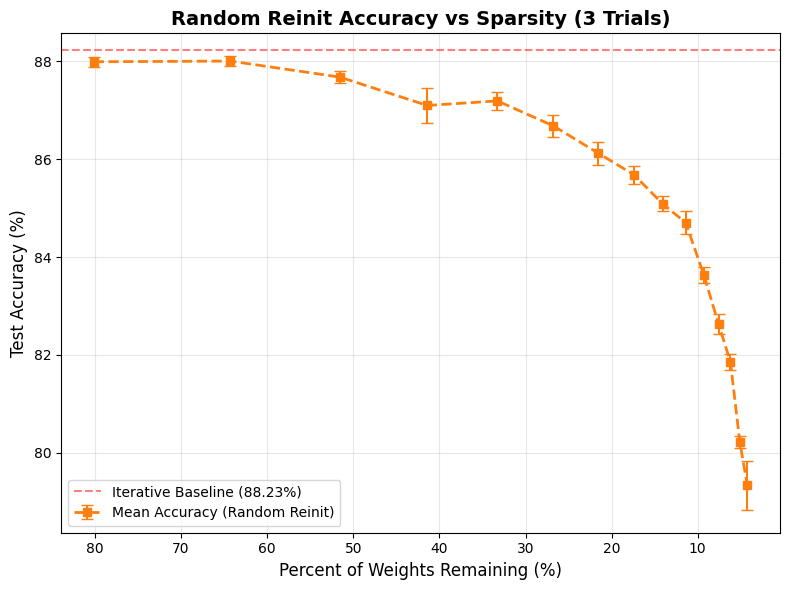

Random init figure saved to: ../../results/resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904/figures/Random_init_results_multi_trial_errorbars_resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904.png


In [15]:
# --- Visualize Random Init with Error Bars ---
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

# Convert to numpy arrays
x_pct_rnd = np.array(remaining_params_pct_rnd)
y_mean_rnd = np.array(acc_means_rnd)
y_std_rnd = np.array(acc_stds_rnd)

# ==============================================================================
# Plot: Accuracy vs Sparsity (Random Init)
# ==============================================================================

# Error bar plot
ax1.errorbar(x_pct_rnd, y_mean_rnd, yerr=y_std_rnd, fmt='s--', 
             linewidth=2, markersize=6, capsize=4, elinewidth=1.5,
             color='tab:orange', ecolor='tab:orange', label='Mean Accuracy (Random Reinit)')

# Baseline Handling (Optional: Compare against Iterative Baseline)
# If 'baseline_mean' exists from the previous iterative block, we can use it.
if 'baseline_mean' in globals():
    ax1.axhline(y=baseline_mean, color='r', linestyle='--', label=f'Iterative Baseline ({baseline_mean:.2f}%)', alpha=0.5)

ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title(f'Random Reinit Accuracy vs Sparsity ({n_trials_rnd} Trials)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.invert_xaxis()  # 100% -> 0%

plt.tight_layout()

# Save Figure
if 'fig_dir' not in globals(): fig_dir = "." 
random_fig_path = os.path.join(fig_dir, f"Random_init_results_multi_trial_errorbars_{run_id}.png")
plt.savefig(random_fig_path, dpi=300)
plt.show()

print(f"Random init figure saved to: {random_fig_path}")

In [16]:
# --- Analyze Random Init Performance (Control) ---

# Use the same baseline as Iterative Pruning if available
if 'baseline_mean_acc' not in globals():
    # Fallback if iterative block wasn't run
    baseline_mean_acc = acc_means_rnd[0]

random_matching_tickets = []

# Loop through aggregated stats
for i in range(n_rounds_rnd):
    # Criteria: Mean Accuracy >= 98% of Baseline
    # This checks if Random Init can essentially "get lucky" and match the original network
    if acc_means_rnd[i] >= baseline_mean_acc * 0.98:
        random_matching_tickets.append(i)

print(f"\n{'='*70}")
print(f"Random Reinit Analysis (Control Experiment)")
print(f"{'='*70}")
print(f"Target Baseline Accuracy: {baseline_mean_acc:.2f}%")
print(f"\nRandom Configurations Matching Baseline (>= {baseline_mean_acc * 0.98:.2f}%):")

if not random_matching_tickets:
    print("None found. (As expected, random reinitialization usually fails at high sparsity)")
else:
    print(f"{'Round':<8} {'Sparsity %':<12} {'Mean Acc %':<12}")
    print("-"*40)
    for idx in random_matching_tickets:
        sparsity = 100 - remaining_params_pct_rnd[idx]
        print(f"{rounds_rnd[idx]:<8} {sparsity:<12.1f} "
              f"{acc_means_rnd[idx]:<12.2f}")

print("="*70)


Random Reinit Analysis (Control Experiment)
Target Baseline Accuracy: 88.23%

Random Configurations Matching Baseline (>= 86.47%):
Round    Sparsity %   Mean Acc %  
----------------------------------------
1        19.8         87.99       
2        35.7         88.00       
3        48.4         87.68       
4        58.6         87.10       
5        66.7         87.19       
6        73.2         86.68       


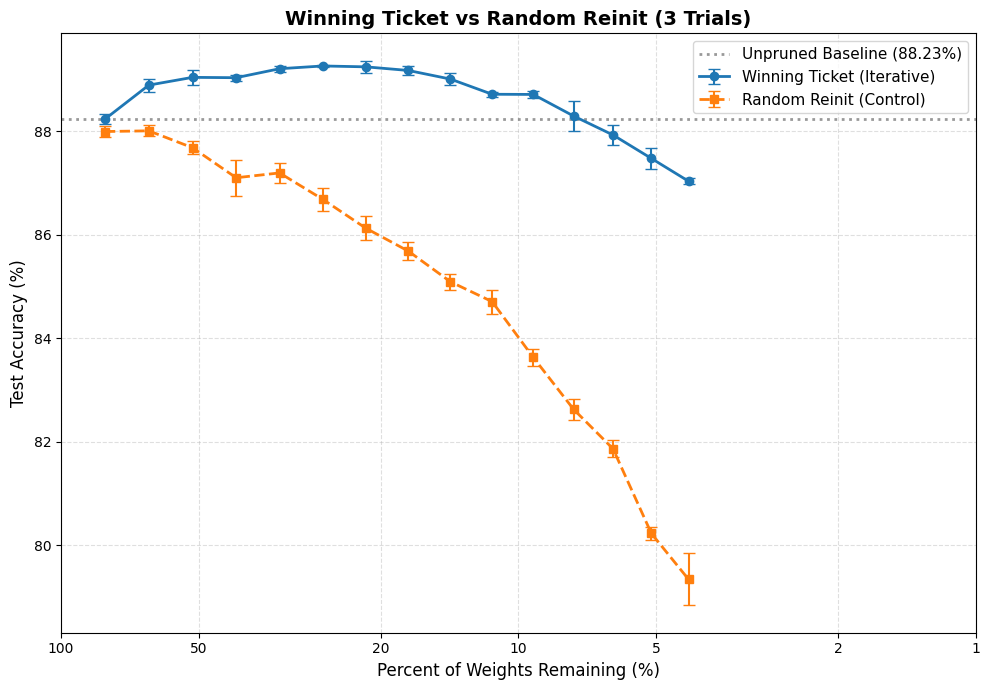

Combined figure saved to: ../../results/resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904/figures/Winning_Ticket_vs_Random_MultiTrial_Final_resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260114_183904.png


In [17]:
# --- Configuration ---
# Ensure these variables exist from your previous cells
# Iterative Data (Winning Ticket)
x_iter = np.array(remaining_params_pct)
y_iter_mean = np.array(acc_means)
y_iter_std = np.array(acc_stds)

# Random Init Data (Control)
x_rnd = np.array(remaining_params_pct_rnd)
y_rnd_mean = np.array(acc_means_rnd)
y_rnd_std = np.array(acc_stds_rnd)

# --- Visualize: Winning Ticket vs Random Reinit (Combined) ---
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# ==============================================================================
# 1. Plot Winning Ticket (Iterative Pruning) -> Solid Line
# ==============================================================================
ax.errorbar(x_iter, y_iter_mean, yerr=y_iter_std, fmt='o-', 
             linewidth=2, markersize=6, capsize=4, elinewidth=1.5,
             color='tab:blue', ecolor='tab:blue', label='Winning Ticket (Iterative)')

# ==============================================================================
# 2. Plot Random Reinit (Control) -> Dashed Line
# ==============================================================================
ax.errorbar(x_rnd, y_rnd_mean, yerr=y_rnd_std, fmt='s--', 
             linewidth=2, markersize=6, capsize=4, elinewidth=1.5,
             color='tab:orange', ecolor='tab:orange', label='Random Reinit (Control)')

# ==============================================================================
# 3. Baseline Handling
# ==============================================================================
# Use the Mean Baseline from the Iterative Pruning (Round 1)
baseline_val = y_iter_mean[0]
ax.axhline(y=baseline_val, color='grey', linestyle=':', linewidth=2, 
           label=f'Unpruned Baseline ({baseline_val:.2f}%)', alpha=0.8)

# ==============================================================================
# 4. Styling (Match Paper Style)
# ==============================================================================
ax.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title(f'Winning Ticket vs Random Reinit ({n_trials} Trials)', fontsize=14, fontweight='bold')

ax.grid(True, which="both", linestyle='--', alpha=0.4)
ax.legend(fontsize=11, loc='best')

# Use Log Scale for X-axis to match Figure 8 style (better visibility for high sparsity)
ax.set_xscale('log')
ax.invert_xaxis()  # 100% -> 0%

# Set Custom Ticks for Log Scale (100, 50, 20, 10, 5, 2, 1)
ticks = [100, 50, 20, 10, 5, 2, 1]
ax.set_xticks(ticks)
ax.set_xticklabels([str(t) for t in ticks])
ax.minorticks_off() # Turn off minor ticks to look cleaner

plt.tight_layout()

# ==============================================================================
# 5. Save Figure
# ==============================================================================
if 'fig_dir' not in globals(): fig_dir = "."
combined_fig_path = os.path.join(fig_dir, f"Winning_Ticket_vs_Random_MultiTrial_Final_{run_id}.png")
plt.savefig(combined_fig_path, dpi=300)
plt.show()

print(f"Combined figure saved to: {combined_fig_path}")

## 6. Analyze Results

### 6.1 Iterative Pruning

Visualize and analyze the pruning results.

## 7. Identify Winning Tickets

Find which pruned networks are "winning tickets" (match or exceed baseline accuracy).

## 8. Save Results

## 9. Next Steps

### Experiment Ideas:

1. **Compare pruning strategies**
   - Try different `prune_rate_conv` and `prune_rate_fc`
   - Compare `layerwise` vs `global` pruning

2. **Random reinitialization baseline**
   - Use `random_reinit_pruning()` to show winning tickets need original initialization

3. **One-shot pruning**
   - Compare `one_shot_pruning()` vs iterative pruning

4. **Visualize weight distributions**
   - Plot weight magnitude histograms before/after pruning

5. **Learning rate experiments**
   - Test different learning rates (paper shows this matters!)

## Notes and Observations

**TODO: Add your observations here**

- What worked well?
- What surprised you?
- Any implementation challenges?
- Ideas for the final report?